In [12]:
import numpy as np
import pandas as pd
from scipy.stats import weibull_min, lognorm, gamma as gamma_dist, norm
from scipy.optimize import minimize
from scipy.special import gammaln, digamma, polygamma
import matplotlib.pyplot as plt

# Config
CONFIG = {
    "CSV_PATH": "/kaggle/input/datasets/tungalavenkata/bluemountainds/machine_1_failures-2.csv",
    "SMP_COL": "SMP",
    "TIME_COL": "FailureTimeDays",
    "CENS_COL": "Censored",
    "FIT_MODE": "all"
}

In [13]:
def pdf_weibull(t, alpha, beta):
    return weibull_min.pdf(t, c=alpha, scale=beta)

def pdf_lognormal(t, mu, sigma):
    return lognorm.pdf(t, s=sigma, scale=np.exp(mu))

def pdf_gamma(t, a, b):
    return gamma_dist.pdf(t, a=a, scale=b)

def surv_weibull(t, alpha, beta):
    return np.exp(-(t / beta) ** alpha)

def surv_lognormal(t, mu, sigma):
    return 1 - norm.cdf((np.log(np.clip(t, 1e-300, None)) - mu) / sigma)

def surv_gamma(t, a, b):
    return 1 - gamma_dist.cdf(t, a=a, scale=b)

In [14]:

def mixture_pdf(t, params):
    alpha, beta, mu, sigma, a, b, p1, p2 = params
    p3 = 1 - p1 - p2

    return (
        p1 * pdf_weibull(t, alpha, beta)
        + p2 * pdf_lognormal(t, mu, sigma)
        + p3 * pdf_gamma(t, a, b)
    ) + 1e-300

def reliability(t, params):
    alpha, beta, mu, sigma, a, b, p1, p2 = params
    p3 = 1 - p1 - p2

    return (
        p1 * surv_weibull(t, alpha, beta)
        + p2 * surv_lognormal(t, mu, sigma)
        + p3 * surv_gamma(t, a, b)
    )

def hazard(t, params):
    return mixture_pdf(t, params) / np.clip(reliability(t, params), 1e-300, None)

def mttf(params):
    alpha, beta, mu, sigma, a, b, p1, p2 = params
    p3 = 1 - p1 - p2

    return (
        p1 * beta * np.exp(gammaln(1 + 1 / alpha))
        + p2 * np.exp(mu + 0.5 * sigma**2)
        + p3 * a * b
    )

In [15]:

def valid_params(params):
    alpha, beta, mu, sigma, a, b, p1, p2 = params
    p3 = 1 - p1 - p2
    return (
        alpha > 0 and beta > 0 and sigma > 0
        and a > 0 and b > 0
        and p1 > 0 and p2 > 0 and p3 > 0
    )

def neg_log_likelihood(params, data, censored):
    if not valid_params(params):
        return 1e10

    t_fail = data[~censored]
    t_cens = data[censored]

    ll = 0
    if len(t_fail) > 0:
        ll += np.sum(np.log(mixture_pdf(t_fail, params)))
    if len(t_cens) > 0:
        ll += np.sum(np.log(reliability(t_cens, params)))

    return -ll

In [16]:

def smart_init(data, censored):
    t = data[~censored] if (~censored).any() else data
    t = t[t > 0]

    m = np.mean(t)
    s = np.std(t) + 1e-6

    mu0 = np.mean(np.log(t))
    sigma0 = max(np.std(np.log(t)), 0.1)

    alpha0 = max(0.5, (m / s) ** 1.2)
    beta0 = m

    b0 = s**2 / m
    a0 = max(0.5, m / b0)

    return [alpha0, beta0, mu0, sigma0, a0, b0, 0.34, 0.33]

In [17]:

def fit_mle(data, censored):
    x0 = smart_init(data, censored)
    t_max = np.max(data)

    bounds = [
        (0.01, None),
        (0.01, t_max * 10),
        (None, None),
        (0.01, None),
        (0.01, None),
        (0.01, t_max * 10),
        (0.01, 0.98),
        (0.01, 0.98),
    ]

    result = minimize(
        neg_log_likelihood,
        x0,
        args=(data, censored),
        method="L-BFGS-B",
        bounds=bounds
    )

    return result.x

In [18]:

def fit_em(data, censored, max_iter=500, tol=1e-6):

    params = smart_init(data, censored)
    prev_ll = -np.inf

    for _ in range(max_iter):

        alpha, beta, mu, sigma, a, b, p1, p2 = params
        p3 = 1 - p1 - p2

        t_fail = data[~censored]

        # E-step
        f1 = p1 * pdf_weibull(t_fail, alpha, beta)
        f2 = p2 * pdf_lognormal(t_fail, mu, sigma)
        f3 = p3 * pdf_gamma(t_fail, a, b)

        total = f1 + f2 + f3 + 1e-300

        w1 = f1 / total
        w2 = f2 / total
        w3 = f3 / total

        # M-step (weights)
        p1 = np.mean(w1)
        p2 = np.mean(w2)
        p3 = np.mean(w3)

        # Normalize
        total = p1 + p2 + p3
        p1, p2, p3 = p1/total, p2/total, p3/total

        # Lognormal update
        mu = np.sum(w2 * np.log(t_fail)) / np.sum(w2)
        sigma = np.sqrt(np.sum(w2 * (np.log(t_fail) - mu)**2) / np.sum(w2))

        params = [alpha, beta, mu, sigma, a, b, p1, p2]

        ll = -neg_log_likelihood(params, data, censored)

        if abs(ll - prev_ll) < tol:
            break

        prev_ll = ll

    return np.array(params)

In [19]:

def compute_metrics(params, data, censored):
    ll = -neg_log_likelihood(params, data, censored)
    n = len(data)
    k = len(params)

    aic = -2 * ll + 2 * k
    bic = -2 * ll + k * np.log(n)

    return ll, aic, bic

In [20]:

def plot_results(data, censored, params_mle, params_em):

    t = np.linspace(min(data), max(data), 500)

    plt.figure(figsize=(10,6))

    plt.plot(t, mixture_pdf(t, params_mle), label="MLE")
    plt.plot(t, mixture_pdf(t, params_em), '--', label="EM")

    plt.hist(data[~censored], bins=20, density=True, alpha=0.3)

    plt.legend()
    plt.title("PDF Comparison")
    plt.show()

Fitting MLE...
Fitting EM...

MLE Params: [ 1.66771746 59.9775617   4.26809744  0.54422918  2.9735039  20.4002946
  0.66450888  0.33354971]
EM Params: [ 1.84837841 60.09794521  4.36943911  0.4704988   2.78388621 21.58778796
  0.79925877  0.19904503]

Metrics (MLE): (np.float64(-1459.8278099015217), np.float64(2935.6556198030435), np.float64(2965.285879600293))
Metrics (EM): (np.float64(-1463.3765024545087), np.float64(2942.7530049090174), np.float64(2972.383264706267))


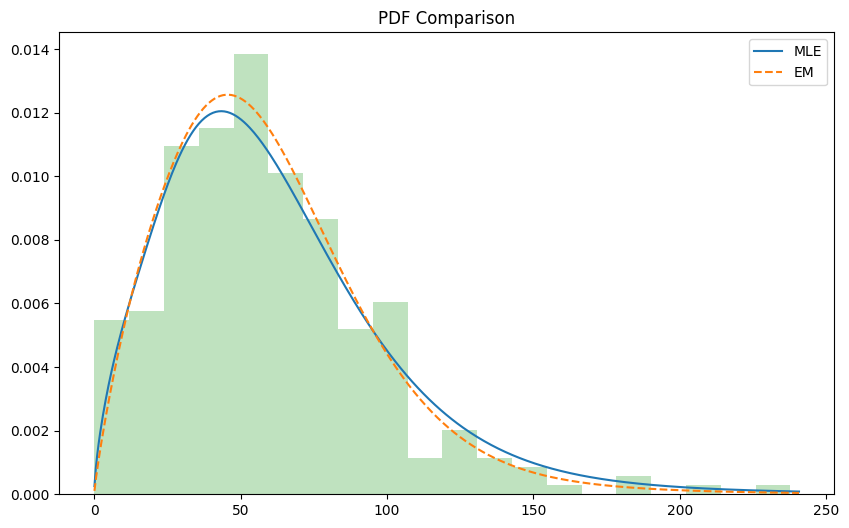

In [21]:

df = pd.read_csv(CONFIG["CSV_PATH"])

data = df[CONFIG["TIME_COL"]].values

if CONFIG["CENS_COL"] in df.columns:
    censored = df[CONFIG["CENS_COL"]].astype(bool).values
else:
    censored = np.zeros_like(data, dtype=bool)

print("Fitting MLE...")
params_mle = fit_mle(data, censored)

print("Fitting EM...")
params_em = fit_em(data, censored)

print("\nMLE Params:", params_mle)
print("EM Params:", params_em)

print("\nMetrics (MLE):", compute_metrics(params_mle, data, censored))
print("Metrics (EM):", compute_metrics(params_em, data, censored))

plot_results(data, censored, params_mle, params_em)